In [42]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


In [43]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from src.utils import compute_bin_stats
from src.plot import interploated_confidence_plot

ImportError: cannot import name 'compute_equal_frequency_bin_stats' from 'src.utils' (/home/lukas/Documents/Uni/Calibration Paper/code2/src/utils.py)

In [ ]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

runs_dir = PROJECT_ROOT / "runs-legacy"
with open(runs_dir / "data.json") as f:
    data = json.load(f)

runs = pd.DataFrame(data)

selected_obj = []
for obj in data:
    if obj["dataset"] != "HotpotQA":
        continue
    if obj["model"] != "gpt-4o":
        continue
    selected_obj.append(obj)

In [40]:
for obj in selected_obj:
        csv_file = obj["csv_file"]
        prompt =  obj["prompt"]
        df = pd.read_csv(runs_dir / csv_file)

In [41]:
bin_stats = compute_bin_stats(df["gpt_eval"], df["confidence"], np.linspace(0,1,11))

In [7]:
bin_stats

,bin,mean_y,std_y,mean_conf,n,mid,start,end,width
0,0.000-0.100,NaN,NaN,NaN,NaN,0.05,0.0,0.1,0.1
1,0.100-0.200,0.000000,0.000000,0.200000,2.0,0.15,0.1,0.2,0.1
2,0.200-0.300,0.000000,0.000000,0.300000,2.0,0.25,0.2,0.3,0.1
3,0.300-0.400,0.000000,0.000000,0.400000,2.0,0.35,0.3,0.4,0.1
4,0.400-0.500,0.000000,NaN,0.500000,1.0,0.45,0.4,0.5,0.1
5,0.500-0.600,0.058824,0.242536,0.600000,17.0,0.55,0.5,0.6,0.1
6,0.600-0.700,0.380000,0.490314,0.700000,50.0,0.65,0.6,0.7,0.1
7,0.700-0.800,0.383838,0.487552,0.799495,198.0,0.75,0.7,0.8,0.1
8,0.800-0.900,0.740433,0.438762,0.899584,601.0,0.85,0.8,0.9,0.1
9,0.900-1.000,0.929134,0.257617,0.983858,127.0,0.95,0.9,1.0,0.1


(0.0, 1.0)

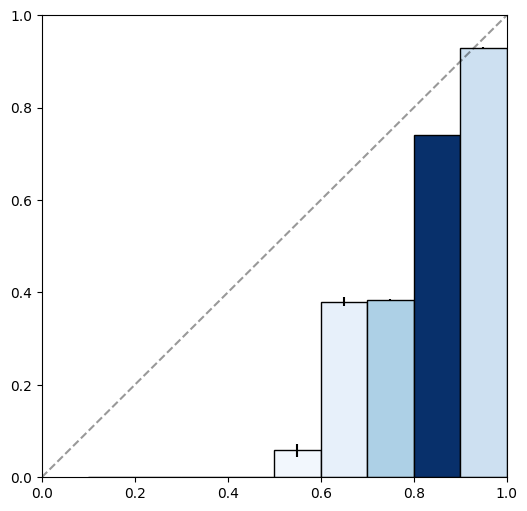

In [31]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors


x = bin_stats["mid"].values
y = bin_stats["mean_y"].values
n = bin_stats["n"].fillna(0).values  # handle NaN safely
y_errs = bin_stats["std_y"].values / n
widths = bin_stats["width"]

norm = mcolors.Normalize(vmin=n.min(), vmax=n.max())
cmap = cm.Blues

plt.figure(figsize=(6,6))

for xi, yi, ni, wi, yerr in zip(x, y, n, widths, y_errs):
    plt.bar(xi, yi, width=wi, color=cmap(norm(ni)), yerr=yerr, edgecolor="black")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.xlim(0, 1)
plt.ylim(0, 1)

In [32]:
bin_stats["n"].sum()

np.float64(1000.0)